<a href="https://colab.research.google.com/github/lab-ia-shared/Cardio-IA-4/blob/main/notebooks/PreProcessamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Montando o Pipeline de Dados...
Found 4438 files belonging to 2 classes.
Using 3551 files for training.
Found 4438 files belonging to 2 classes.
Using 887 files for validation.
Found 1114 files belonging to 2 classes.

Pipeline de Dados criado com sucesso
Os dados estão prontos para alimentar a CNN


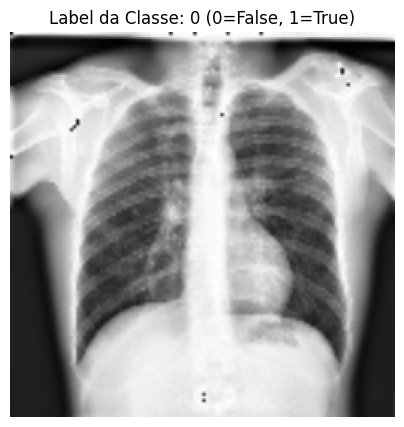

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Conecta o Google Drive ao Colab
drive.mount('/content/drive')

# Caminhos para as pastas
DATASET_PATH = "/content/drive/MyDrive/CardioIA_Datasets/dados_visuais/Cardiomegaly Disease Prediction Using CNN"
TRAIN_DIR = f"{DATASET_PATH}/train"
TEST_DIR = f"{DATASET_PATH}/test"

IMG_SIZE = (224, 224) # Redimensionamento Padrão
BATCH_SIZE = 32

print("\nMontando o Pipeline de Dados...")

# 2. Conjunto de Treino (Pegando 80% da pasta 'train')
# Divisão do Dataset (Treino e Validação)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2, # Separa 20% para validação
    subset="training",
    seed=42, # Garante que a divisão seja sempre a mesma
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary' # Temos 2 classes: false e true
)

# 3. Conjunto de Validação
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 4. Conjunto de Teste
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 5.Normalização dos Pixels (Escala 0 a 1)
# camada de normalização que será aplicada durante a passagem dos lotes
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Aplicando a normalização nos 3 conjuntos
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# Otimização de performance do pipeline para evitar gargalos de I/O no Drive
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("\nPipeline de Dados criado com sucesso")
print("Os dados estão prontos para alimentar a CNN")

# Exibir uma imagem do primeiro lote para validação visual
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(5, 5))
    plt.imshow(images[0].numpy())
    plt.title(f"Label da Classe: {int(labels[0])} (0=False, 1=True)")
    plt.axis("off")
    plt.show()
    break

In [4]:
# primeiro lote de imagens e rótulos
for images, labels in train_dataset.take(1):
    # Imprime o formato matemático do tensor da primeira imagem
    print("Formato real do Tensor da imagem:", images[0].shape)
    break

Formato real do Tensor da imagem: (224, 224, 3)
